# Business Club Summer Camp 2026

## P7 

#### Below we wrote the flow of our notebook (like an index or reference)

------

## Datasets used : 
- `train.csv` : 2k customers used for our EDA & training of mdoels
-  `test.csv` : 500 customers used for the model evaluation & assign the risk scores

  
-  `features used :` `Account_Age`, `Daily_Usage_Mins`, `Login_Frequency` .

> **Imp Note:**
> We removed the `last_support_Ticket` col. (or dropped) : as the NLP analysis wasnt possible for me.
> 
> Other cols : ('customer_id', 'name', 'email') were dropped as they can only used as identification not as a predictive indicator


---
### Phases in Notebook : 

- `Phase 1` : EDA & Analysed churn patterns with `Account_Age`, `Daily_Usage_Mins`, `Login_Frequency`
- `Phase 2` : Feature Engineering and training 3 models 
- `Phase 3` : Risk Scorecard , high_risk customers ordered dataset, business recommendations.



In [1]:
import numpy as np
import pandas as pd 
import sklearn 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
df_train = pd.read_csv('train.csv')


In [3]:
df_train.sample(5)

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn
147,f02296ce-a5a0-4158-a992-80d1b8113f87,Ashley Estrada,laurawoods@example.com,66,Rarely,10,Your API documentation is outdated and full of...,1
1771,c185533e-810c-432f-8b17-f96c33cea9c8,Alyssa Prince,anthonybowen@example.org,90,Weekly,52,Can I add more seats to my current plan?,0
1820,4527b05f-10f1-440e-b62e-f896e5e0bb03,Erin Flynn,jsmith@example.com,163,Daily,31,Can I add more seats to my current plan?,0
1481,1f99c710-5cfa-46ca-9343-73bbc7ce49ed,Joseph Noble,porternicholas@example.com,64,Weekly,26,Just checking if my payment went through.,1
1115,f9eb49bd-b9d1-43ba-a100-9776b1f03bfb,Becky Fisher,pclark@example.com,296,Daily,56,I love the new analytics feature! Great job.,0


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Customer_ID          2000 non-null   str  
 1   Name                 2000 non-null   str  
 2   Email                2000 non-null   str  
 3   Account_Age_Days     2000 non-null   int64
 4   Login_Frequency      2000 non-null   str  
 5   Daily_Usage_Mins     2000 non-null   int64
 6   Last_Support_Ticket  2000 non-null   str  
 7   Churn                2000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 125.1 KB


In [5]:
print("Num. of duplicates before : ")
print(df_train.duplicated().sum())

Num. of duplicates before : 
0


In [6]:
df_train = df_train.drop(columns=[
    "Customer_ID", "Name", "Email", "Last_Support_Ticket"
    ])
df_train.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
0,790,Weekly,28,0
1,399,Daily,28,1
2,646,Daily,110,0
3,113,Weekly,21,0
4,322,Weekly,7,1


In [7]:

df_train.shape


(2000, 4)

In [8]:
df_train.dtypes

Account_Age_Days    int64
Login_Frequency       str
Daily_Usage_Mins    int64
Churn               int64
dtype: object

In [9]:
df_train.describe()

,Account_Age_Days,Daily_Usage_Mins,Churn
count,2000.000000,2000.0000,2000.000000
mean,560.969500,36.1610,0.368500
std,317.349495,29.1486,0.482519
min,1.000000,1.0000,0.000000
25%,287.750000,11.0000,0.000000
50%,565.000000,30.0000,0.000000
75%,840.000000,53.0000,1.000000
max,1094.000000,119.0000,1.000000


In [10]:
print("Null Report")
df_train.isnull().sum()

Null Report


Account_Age_Days    0
Login_Frequency     0
Daily_Usage_Mins    0
Churn               0
dtype: int64

In [11]:
df_test = pd.read_csv('test.csv')

In [12]:
df_test.shape

(500, 8)

In [13]:
actual_test = df_test.copy()

In [14]:
df_test.isnull().sum()

Customer_ID            0
Name                   0
Email                  0
Account_Age_Days       0
Login_Frequency        0
Daily_Usage_Mins       0
Last_Support_Ticket    0
Churn                  0
dtype: int64

In [15]:
print("Churn % : ")
print("Train :", df_train['Churn'].value_counts(normalize=True)*100)
print("--"*20)
print("Test :", df_test['Churn'].value_counts(normalize=True)*100)



Churn % : 
Train : Churn
0    63.15
1    36.85
Name: proportion, dtype: float64
----------------------------------------
Test : Churn
0    65.8
1    34.2
Name: proportion, dtype: float64


<!-- ### Univariate Analysis: -->

In [16]:
print("Num. of duplicates after : ")
print(df_train.duplicated().sum())

Num. of duplicates after : 
13


These Duplicates formed on removing those 4 columns which were the differentiating factor for these 13 rows. 

Removing the duplicates is just to maintain no biasness in data , which hampers the prediction model.

We will also remove the same columns from the test dataset. 

In [17]:
df_test = df_test.drop(columns=[
    "Customer_ID", "Name", "Email", "Last_Support_Ticket"
    ])
print("Top 5 entries of test  :\n",df_test.head())
print("--"*30)
print("Shape of test dataset  :",df_test.shape)


Top 5 entries of test  :
    Account_Age_Days Login_Frequency  Daily_Usage_Mins  Churn
0               269           Daily                43      0
1               439          Rarely                 9      1
2                18          Rarely                 1      1
3               405           Daily                22      0
4                24           Daily                88      0
------------------------------------------------------------
Shape of test dataset  : (500, 4)


### Important Point : 

As u saw , we removed the **`Last_Support_Ticket`** column because NLP is beyond my scope . 
After reading and understanding what this colm actually represent, it is crystal clear that it is one the strongest indeicator or most valuable feature predicting the customer churn.

One who can do NLP extraction from this , their model can predict churn more accurately as this column contains the actual difficulties customers faced on accessing the platform , what they were not able to find , things or features which were more like confusion to them instead of useful . 

By applying the NLP techniq , one can convert this column into meaningful numerical features for ML model

### Acoount Age vs Churn

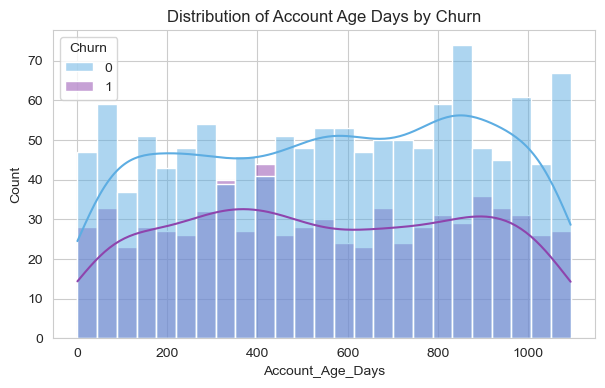

In [18]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(
    data = df_train,
    x='Account_Age_Days',
    hue='Churn',
    bins=25,
    kde=True,
    palette= { 0: '#5DADE2',
               1: '#8E44AD'},
    ax = ax
)
ax.set_title('Distribution of Account Age Days by Churn')

plt.show()




### Que 2 : distribution of tenure among churned customer vs stayed 

Used `Account_Age_Days` as `tenure` 

In [19]:
print(50*"-")

print("\nDestribution of churn on age of account : ")
df_train.groupby('Churn')['Account_Age_Days'].describe()





--------------------------------------------------

Destribution of churn on age of account : 


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,1263.0,568.492478,319.093714,1.0,288.0,582.0,844.5,1094.0
1,737.0,548.077341,314.134574,9.0,283.0,534.0,826.0,1093.0


In [20]:
print(50*"-")
print("Correlation age & churn: \n")

df_train[['Account_Age_Days', 'Churn']].corr()

--------------------------------------------------
Correlation age & churn: 



,Account_Age_Days,Churn
Account_Age_Days,1.00000,-0.03104
Churn,-0.03104,1.00000


#### Insights : 
- average acc. age of "not-churned custm" is `~568 days` while that of "churned custm." is `~548 days` : Only th2 `20days` (relatively quite small)difference .

- from the distribution , we can see for `Q1`,`Q2`and `Q3`: retained and churned customers distribution is almost similar

- the correlation bw `Account_Age_Days` & `Churn` is : `-0.031` ~ very close to 0.
  (case of exterme weak negative linear relnsip)

  
<!-- long tenured users churns at same rate as new ones . 
Therefore will not be considering ( least considering ) the `loyalty` in our retention strategy .  -->
--------------------------------------
#### Conclusions': 

The `tenure` or `Account age` alone cant be considered a strong factor which influences the custm. churn. 
it may predict churn when further we use it with other features. 

### Daily usage mins vs Churn

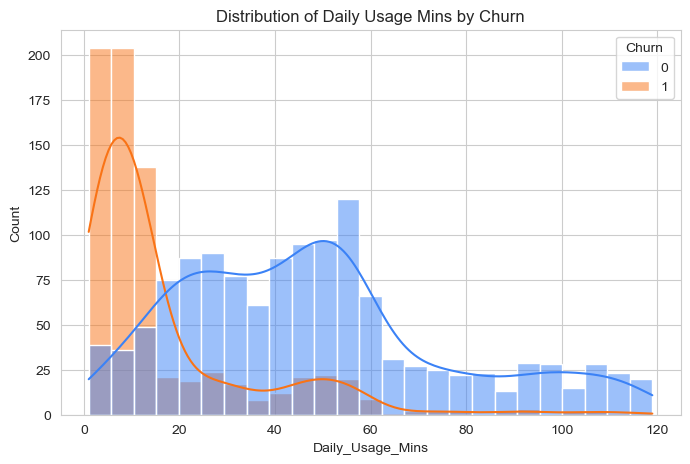

In [21]:
fig, ax= plt.subplots(figsize=(8,5))

sns.histplot(
    data = df_train,
    x='Daily_Usage_Mins',
    hue='Churn',
    bins=25,
    kde=True,
    palette= { 0 : '#3B82F6',
               1: '#F97316'},
    ax =ax
)
ax.set_title('Distribution of Daily Usage Mins by Churn')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_23064\3990355106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


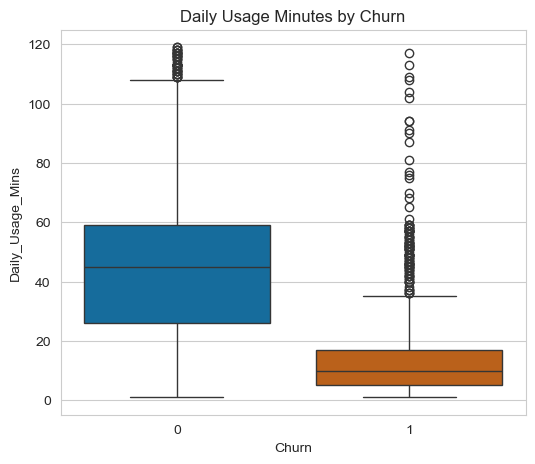

In [22]:
plt.figure(figsize= (6,5))

sns.boxplot(
    data=df_train,
    x='Churn',
    y='Daily_Usage_Mins',
    palette={ '0': '#0072B2',
              '1': '#D55E00'
            }
    
        
)

plt.title('Daily Usage Minutes by Churn')
plt.show()

In [23]:
print(50*"-")

print("\nDestribution of churn on daily Usage mins  : ")

df_train.groupby('Churn')['Daily_Usage_Mins'].describe()

--------------------------------------------------

Destribution of churn on daily Usage mins  : 


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,1263.0,47.682502,27.847469,1.0,26.0,45.0,59.0,119.0
1,737.0,16.416554,18.968048,1.0,5.0,10.0,17.0,117.0


In [24]:
print(50*"-")
print("Correlation age & usage daily mins: \n")

df_train[['Daily_Usage_Mins', 'Churn']].corr()



--------------------------------------------------
Correlation age & usage daily mins: 



,Daily_Usage_Mins,Churn
Daily_Usage_Mins,1.000000,-0.517569
Churn,-0.517569,1.000000


#### Insights :

- custmers stayed are having average use mins as roughly `48 mins per day`, where the churned custm. had average use mins of : `16 mins per day`, which is around `1/3 rd` of the engagement lvl

- Q2 val ( median or 50%) shows the same pattern as our boxplot  :
     - retained : `45 mins`
     - churned : `10-15 mins`

- Same with the Q1(of retained : `26 mins`) and Q3(of churned : `17 mins`) same pattern:
   - clearly shows the BIG DIFFERENCE bw these 2 groups of custm.


- the correlation bw daily usage mins and churn is `0.517` : moderate to strong negative reln
   - shows if the usage incs. the pribability of churn is low
 
- many or most of the churned custm. are low_usage users and also there is a small group of high_usage users churned : which says like "engagement" alone cannot be the only factor which is influencing the churn rate.

---------------------------------------

#### Conclusions : 

- daily usage mins : stronger candidate in predicting behaviour of customer churn

- custm. with low engagement are knowingly more likely to churn, whereas users who are more active tends to remain loyal.
  - this makes us to believe in : customer engagement plays a prominent or critical role in retention .
 
- also suggests **"low daily usage is The early indicator of churn risk"** , it can appear before any explicit complaint or cancellation behaviour.

- for the business pov : this "Daily usage" can be monitored in Real_tIME to immediately identify customers at_risk and trigger the retention strategies.


- so basically , will be considering this "Daily_Usage_Mins" as key predictive feature for the churn prediction and in retention strategies.

### Login freq. vs Churn

In [25]:
print("\n")
v=df_train['Login_Frequency'].value_counts()
print("-"*30)

print("Frequency Counts: ")
print("-"*30)
print(v)
print("\n")

print("-"*30)
print("Churn rate ( category wise) : ")
print("-"*30)

pd.crosstab(
    df_train['Login_Frequency'],
    df_train['Churn'],
    normalize='index'
)*100



------------------------------
Frequency Counts: 
------------------------------
Login_Frequency
Daily     868
Weekly    795
Rarely    337
Name: count, dtype: int64


------------------------------
Churn rate ( category wise) : 
------------------------------


Churn,0,1
Login_Frequency,,
Daily,86.981567,13.018433
Rarely,14.540059,85.459941
Weekly,57.735849,42.264151


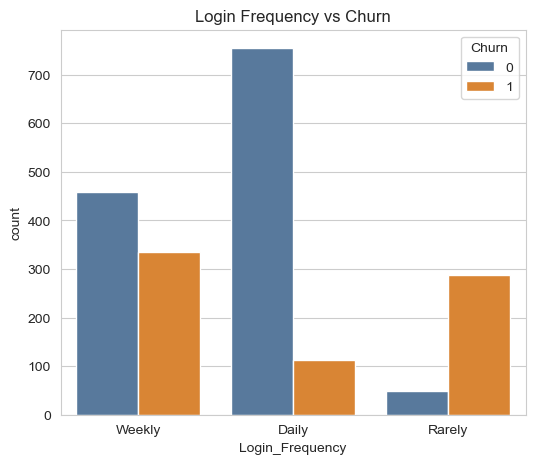

In [26]:
plt.figure(figsize =(6,5))

sns.countplot(
    data=df_train,
    x='Login_Frequency',
    hue='Churn',
    palette ={ 0:"#4C78A8",
               1: "#F58518"
             } 
)

plt.title('Login Frequency vs Churn')

plt.show()

Text(0.5, 1.0, 'Churn rate by login freq.')

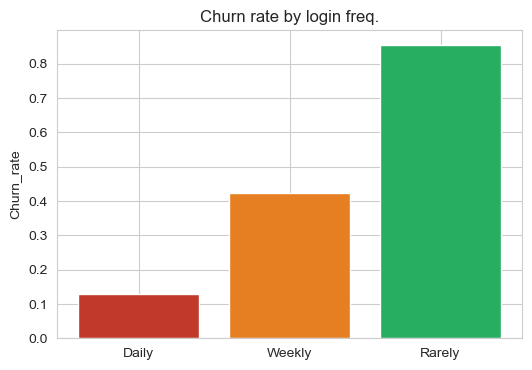

In [27]:
fig, ax=plt.subplots(figsize=(6,4))

login_rate =df_train.groupby('Login_Frequency')['Churn'].mean().sort_values()

ax.bar(
    login_rate.index,
    login_rate.values,
    color=['#C0392B','#E67E22','#27AE60']
)

ax.set_ylabel('Churn_rate')
ax.set_title('Churn rate by login freq.')

#### Insights:

- Strong relationship bw login freq & churn behaviour.

- `daily login` custm. shows lowest churn rate of approx : `13%`
   - very strong retention in highly active users.


- custm. who logs in `rarely` : got extreme high churn rate of about `85%` ,
   - making this is the high-risk segment in dataset.


- `Weekly users` comes in middle with a churn rate of around `42%`
   - moderate activeness but still at some retention risk.


- highest churn concentration is **heavily skewed** toward the `Rarely` category
  - most customers are either the "daily" or just weekly users.
 
- **Login consistency is the strong predictor of churn** & the low platform interaction strongly directs to customer inactiveness & eventually churn behaviour.


----------------------------------------

#### Conclusions:

- Like "daily usage mins" , `login frequency` is also the strongest indicator of churn behaviour.

- **Engagement consistency >>>> occasional usage spikes**.
  - Monitoring login patterns can help in identifying at_risk custm. early so that we can activate the retention strategies. 


    

### Mixing all indicators

In [28]:
df_train.groupby(['Login_Frequency','Churn'])['Daily_Usage_Mins'].mean()

Login_Frequency  Churn
Daily            0        58.862252
                 1        44.716814
Rarely           0         8.020408
                 1         7.013889
Weekly           0        33.527233
                 1        14.958333
Name: Daily_Usage_Mins, dtype: float64

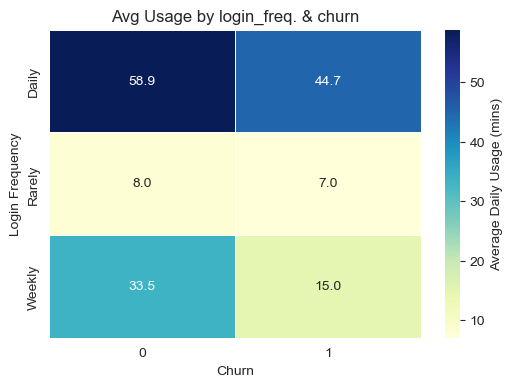

In [29]:
pivot = df_train.pivot_table(
    values='Daily_Usage_Mins',
    index='Login_Frequency',
    columns='Churn',
    aggfunc='mean'
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot,
            annot=True,
            fmt=".1f",
            cmap='YlGnBu',
            linewidth=0.5,
            cbar_kws={'label': 'Average Daily Usage (mins)'}
           )
plt.title("Avg Usage by login_freq. & churn")
plt.xlabel("Churn")
plt.ylabel("Login Frequency")

plt.show()

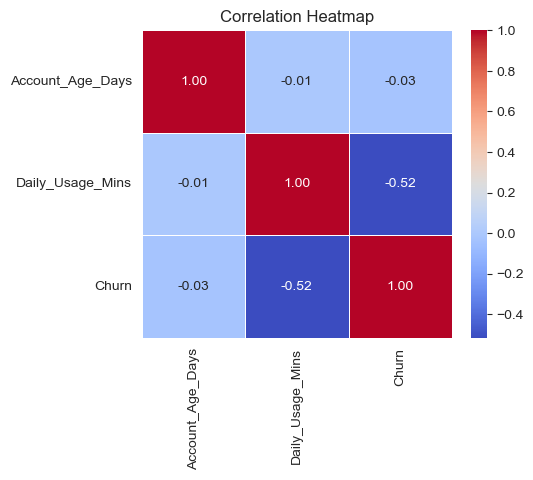

In [30]:
plt.figure(figsize=(5,4))

corr=df_train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

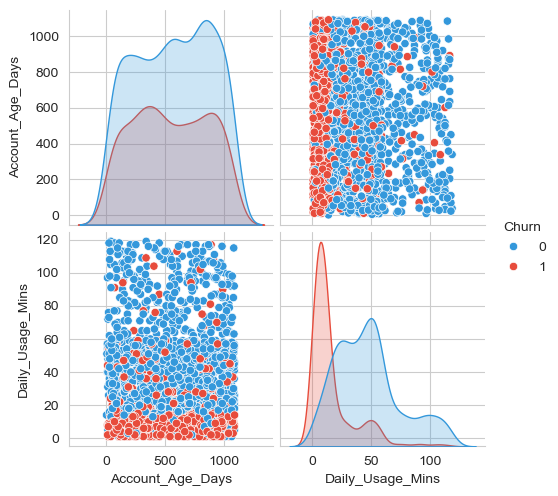

In [31]:
sns.pairplot(
    df_train[['Account_Age_Days','Daily_Usage_Mins','Churn']],
    hue='Churn',
    palette={0:'#3498DB', 
             1:'#E74C3C'
            },
    diag_kind='kde'
)

plt.show()

### Phase 1 QnA :

**q1** . How does churn rate change as tenure increases , and what tenure range has the highest churn concentration

**ans** : 

Age_bucket
0-200          37.393768
200-400        39.255014
400-600        37.569061
600-800        37.110482
800-1000       35.294118
1000-beyond    32.571429
Name: Churn, dtype: float64


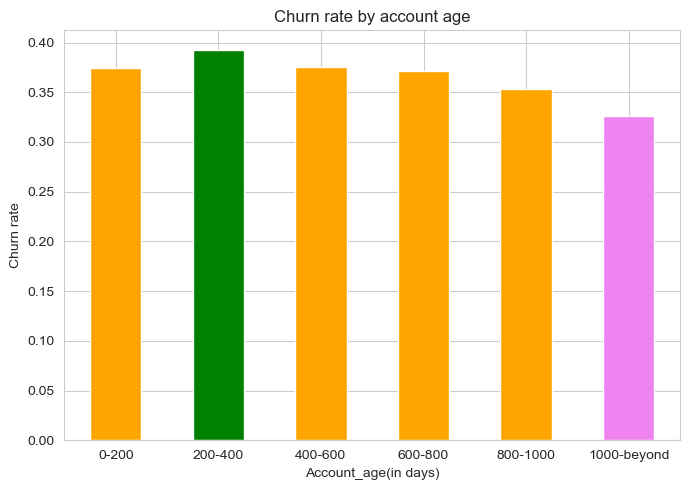

In [32]:
df_train['Age_bucket']=pd.cut(
    df_train['Account_Age_Days'],
    bins=[0,200,400,600,800,1000,1200],
    labels=['0-200', '200-400','400-600','600-800', '800-1000', '1000-beyond']
)

age_churn =df_train.groupby('Age_bucket')['Churn'].mean()
print(age_churn*100)

fig,ax= plt.subplots(figsize=(7,5))

colors = ['Orange'] * len(age_churn)
colors[1] = 'Green'
colors[5] = 'Violet'

age_churn.plot(
               kind='bar', 
               color=colors, 
               ax=ax
             )
ax.set_ylabel('Churn rate')
ax.set_xlabel('Account_age(in days)')
ax.set_title('Churn rate by account age')

plt.xticks(rotation =0)
plt.tight_layout()
plt.show()

Ans2 : 
- Churn rates remain constant or stable across the most of the tenure groups. (range : `[35,39]`
- Account age bw **200-400** shows the highest churn (`~39%`) , but also the churn rate slowly declines with longer account age.
   - the account age with more than 1000+ days got the lowest churn rate  `~32%`
 
- the difference between the churn rates of different account age is okayish . which also showed our previous analysis that : account age has kinda weak realtionship with churn. 

In [33]:
df_train.columns.tolist()

['Account_Age_Days',
 'Login_Frequency',
 'Daily_Usage_Mins',
 'Churn',
 'Age_bucket']

In [34]:
df_train.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn,Age_bucket
0,790,Weekly,28,0,600-800
1,399,Daily,28,1,200-400
2,646,Daily,110,0,600-800
3,113,Weekly,21,0,0-200
4,322,Weekly,7,1,200-400


In [35]:
df_test.columns.tolist()

['Account_Age_Days', 'Login_Frequency', 'Daily_Usage_Mins', 'Churn']

In [36]:
df_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
0,269,Daily,43,0
1,439,Rarely,9,1
2,18,Rarely,1,1
3,405,Daily,22,0
4,24,Daily,88,0


#### Feature Engineering : 

##### Ordinal Encoding

`Login_Frequency` is str type column and the model read numbers. 

As we saw it has : "Daily", "Weekly" and "Rarely" : categorical values .

Unlike the nominal categories, these values have the **natural order** based on the user activity : 

- Rarely -> Lowest engagement ( 0 )
- Weekly -> Moderate engagement (1 )
- Daily -> Highest engagement (2)

We used the `Ordinal Encoding` (preserving the ranking of categories by assigning 0,1,2)



In [37]:
train_df = df_train.copy()
test_df = df_test.copy()

In [38]:
train_df = train_df.drop(columns="Age_bucket")

In [39]:
train_df.columns.tolist()

['Account_Age_Days', 'Login_Frequency', 'Daily_Usage_Mins', 'Churn']

Here we copied the dataframes of test and train and removed the odd columns, to perform further feature engineering and train the model . 

Our original df_train and df_test remain untouched. 
we can easily try different preprocessing tehcniques without doing any hoch poch or reloading it again n again also it will be easier to debug 


In [40]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Rarely', 'Weekly', 'Daily']])


In [41]:
## Best practice : fit on train , transform test
train_df['Login_Frequency'] = oe.fit_transform(
    train_df[['Login_Frequency']]
).astype(int)

test_df['Login_Frequency'] = oe.transform(
    test_df[['Login_Frequency']]
).astype(int)

In [42]:
########## FEATURES ################
X_train = train_df.drop(columns="Churn")
X_test = test_df.drop(columns="Churn")

#********** Target **************#

y_train = train_df["Churn"]
y_test = test_df["Churn"]

In [43]:
print("Shape of x_train:",X_train.shape)
print("Shape of x_test:",X_test.shape)

Shape of x_train: (2000, 3)
Shape of x_test: (500, 3)


In [44]:
print("Shape of y_train:",y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of y_train: (2000,)
Shape of y_test: (500,)


In [45]:
X_train.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins
0,790,1,28
1,399,2,28
2,646,2,110
3,113,1,21
4,322,1,7


In [46]:
X_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins
0,269,2,43
1,439,0,9
2,18,0,1
3,405,2,22
4,24,2,88


### Advised : 
Before proceedig further for training a model, one should check the features matrices & the target vectors . to ensure that the numbher of samples in the features matches the target labels respectively and confirms that data is ready for model training.

## Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter = 1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

y_lr_predcn =lr.predict(X_test)
y_lr_prblty =lr.predict_proba(X_test)[:, 1]

## Will print the report of this model , for understanding : 

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("--"*10 , "Report : Logistic_Regressiion ", "--"*10)
print(classification_report(y_test, y_lr_predcn))

lr_op= {
    "model_name": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_lr_predcn),
    "F1" : f1_score(y_test,y_lr_predcn),
    "roc_auc": roc_auc_score(y_test, y_lr_prblty)
}

print(lr_op)

-------------------- Report : Logistic_Regressiion  --------------------
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       329
           1       0.63      0.68      0.66       171

    accuracy                           0.76       500
   macro avg       0.73      0.74      0.73       500
weighted avg       0.76      0.76      0.76       500

{'model_name': 'Logistic Regression', 'accuracy': 0.756, 'F1': 0.6573033707865169, 'roc_auc': 0.7904690805026751}


## Insights on our Logistic Regression model

- Our LR model achieved :
   - accuracy ~76%
   - roc-auc ~0.79
- it performed well on identifying the non_churning custm.(0), with a strong precision & recall.
     - performance on churned_custm. is kinda mid or say moderate (missed some churned cases)
   
- Our model shows a moderate-good ability in ranking customers by churn_risk (roc_auc to testify this : 0.79)
  - which mkaes this model can be useful in early identification of at_risk customers.





<!-- # ## 📊 Logistic Regression – Model Explanation & Insights

# We started with Logistic Regression as our baseline classification model for predicting customer churn.

# ---

# ### 🔹 Why Logistic Regression?

# Logistic Regression is a simple and interpretable model that works well for binary classification problems like churn prediction (0 = Not Churn, 1 = Churn).  
# It also provides probability outputs, which help in understanding churn risk.

# ---

# ### 🔹 Code Breakdown (Important Steps)

# ```python
# lr = LogisticRegression(
#     max_iter=1000,
#     class_weight='balanced',
#     random_state=42
# )
# ```

# #### ✔ max_iter=1000
# We increased the number of iterations to ensure the model converges properly during training.  
# Sometimes default iterations are not enough, which can lead to warnings or incomplete learning.

# ---

# #### ✔ class_weight='balanced'
# Since the dataset has imbalance between churn and non-churn customers, this parameter ensures:
# - The model gives equal importance to both classes
# - Improves detection of churn customers (minority class)

# Without this, the model may bias toward predicting "not churn".

# ---

# #### ✔ random_state=42
# This ensures reproducibility of results.  
# It makes sure that every time the code runs, we get the same train-test behavior and same results.

# ---

# ### 🔹 Training the Model

# ```python
# lr.fit(X_train, y_train)
# ```

# This step allows the model to learn patterns from historical customer data.

# - X_train → input features (usage, account age, login frequency)
# - y_train → actual churn labels

# ---

# ### 🔹 Predictions

# ```python
# y_lr_pred = lr.predict(X_test)
# y_lr_prob = lr.predict_proba(X_test)[:, 1]
# ```

# We use two types of outputs:

# - `predict()` → gives final class (0 or 1)
# - `predict_proba()` → gives probability of churn (important for ROC-AUC and risk scoring)

# ---

# ### 🔹 Model Performance

# ```
# Accuracy: 75.6%
# F1-score: 0.657
# ROC-AUC: 0.79
# ```

# ---

# ### 🔹 Interpretation of Results

# - **Accuracy (75.6%)** → Model correctly predicts churn/non-churn in most cases
# - **F1-score (0.657)** → Balanced performance between precision and recall for churn detection
# - **ROC-AUC (0.79)** → Good ability to distinguish between churn and non-churn customers

# ---

# ### 🔹 Key Business Insight

# The model performs well in identifying non-churning customers, but performance on churned customers is moderate.

# However, the ROC-AUC score shows that the model is good at ranking customers based on churn risk, which is useful for targeting high-risk customers for retention strategies.

# ---

# ### 🔹 Final Conclusion

# Logistic Regression serves as a strong baseline model for this problem.  
# It provides interpretable results and reasonable predictive performance, making it suitable for early-stage churn analysis and business decision-making. -->

## Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier

dct=  DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

dct.fit(X_train, y_train)

y_dct_predcn = dct.predict(X_test)
y_dct_prblty =dct.predict_proba(X_test)[:, 1]


from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("--"*10,"Report : Decision_Tree ","--"*10)
print(classification_report(y_test, y_dct_predcn))

dct_op= {
    "model_name": "decision_tree",
    "accuracy": accuracy_score(y_test, y_dct_predcn),
    "F1": f1_score(y_test, y_dct_predcn),
    "roc_auc": roc_auc_score(y_test, y_dct_prblty)
}

print(dct_op)


-------------------- Report : Decision_Tree  --------------------
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       329
           1       0.77      0.64      0.70       171

    accuracy                           0.81       500
   macro avg       0.80      0.77      0.78       500
weighted avg       0.81      0.81      0.81       500

{'model_name': 'decision_tree', 'accuracy': 0.814, 'F1': 0.7028753993610224, 'roc_auc': 0.77616914626993}


## Insights on our Decision Tree model

- Our DcT model achieved :
   - accuracy ~81%
   - roc_auc : ~0.77
   - f1_Scr ~0.70 (class 1)

- it performed well in identification on non_churning custm.(0) with a strong recall ~90% & precision
  - which means our model correctly captures the loyal or most loyal customrs

- also performance on identifying churned_customers(1) is **improved** compred to LR
   - f1 score incremented
   - gud-avg balance bw precisiion & recall
      - BUT it still missed some churned customer cases ( to testify : recall : ~64%)


- conclusion can be .. this dct model shows a strong ability to classify 1 and 0 customers ,
   - also learned non_linear patterns better than our LR model
 
- also IMPORTANT point :
  - ROC_AUC Score comparison :
      - Logistic Regression : 0.79
      - Decision Trees : 0.77
  - classification accuracy is fine here but it is still bit slightly weaker in ranking customers by churn probability.

## Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier 

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_rf_predcn=rf.predict(X_test)
y_rf_prblty=rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("--"*10, "Report : Random_Forest", "--"*10)
print(classification_report(y_test,y_rf_predcn))

rf_op={
    "model_name": "Randome_forest",
    "accuracy": accuracy_score(y_test, y_rf_predcn),
    "F1": f1_score(y_test, y_rf_predcn),
    "roc_auc": roc_auc_score(y_test, y_rf_prblty)
}

print(rf_op)

-------------------- Report : Random_Forest --------------------
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       329
           1       0.81      0.64      0.71       171

    accuracy                           0.82       500
   macro avg       0.82      0.78      0.79       500
weighted avg       0.82      0.82      0.82       500

{'model_name': 'Randome_forest', 'accuracy': 0.824, 'F1': 0.7124183006535948, 'roc_auc': 0.7955882614337262}


## Insights on our Random Forest model

- Our Rnadom forest model achieved :
   - accuracy : ~82.4%
   - f1 score: 0.71
   - roc_auc = 0.796

- Our model performed strongly in identification of retained customers (class 0) with the precission of 83% & precision 92% :D
   - which means this rf model very correctly identifies the most of the retained    customers and reducing the false churn prediction

- For the churning cutomers (class 1) our model achieved precision ~81% & recall ~64%  :)
   - this recall shows that the model will predict churn correctly most of the time but still misses actual churners.


- Comparing it with Dct model :
   - Improvements :
        - Accuracy : 81.4% to 82.4%
        - f1_score : 0.70 to 0.71
        - roc_auc : 0.78 to 0.80
   - these data shows that random forest provides better customer ranking ability



In [50]:
fe =rf.feature_importances_
fe

array([0.06411845, 0.27489573, 0.66098582])

In [51]:
df_fe = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": fe
})

df_fe= df_fe.sort_values(
    by="Importance",
    ascending=False
)

df_fe


,Feature,Importance
2,Daily_Usage_Mins,0.660986
1,Login_Frequency,0.274896
0,Account_Age_Days,0.064118


### Insights on Feature importance: 

- `Daily_Usage_Mins` is the strongest feature and the most influential one : contributes around `66%` in decision making of model

- `Login_Frequency` is 2nd important factor : contributes `28%`.

- `Account_Age_Days` smallest impact with `6%` importance .


In [52]:
df_op = pd.DataFrame([lr_op,dct_op, rf_op])

df_op

,model_name,accuracy,F1,roc_auc
0,Logistic Regression,0.756,0.657303,0.790469
1,decision_tree,0.814,0.702875,0.776169
2,Randome_forest,0.824,0.712418,0.795588


In [53]:
output = actual_test.copy()

output["Predicted_Churn"]=y_rf_predcn
output["Risk_score"]=y_rf_prblty

output.head()

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Predicted_Churn,Risk_score
0,068b54d7-7461-4d1c-885e-f5b43efed384,Alyssa Clark,shawn43@example.com,269,Daily,43,Just checking if my payment went through.,0,0,0.263293
1,5d1e924a-5232-4255-8df9-610e13465816,Dr. David Austin MD,woodlydia@example.com,439,Rarely,9,The UI is too confusing. I can't find the expo...,1,1,0.896014
2,c07c0a8a-bac0-47f9-b93d-57d61490a610,Dorothy Rose,naguirre@example.org,18,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.939032
3,cfc0646f-0927-4e8e-b40f-75090340aa0a,Miranda Gilbert,xbauer@example.com,405,Daily,22,Is there a tutorial for the new dashboard feat...,0,0,0.348123
4,67855f87-2552-4273-9aff-1b2060638673,Adam Hayden,austinolivia@example.org,24,Daily,88,"Just upgraded to the Pro plan, excited to use it.",0,0,0.121656


In [54]:

output["risk_cat"]=pd.cut(
    output["Risk_score"],
    bins=[0,0.4,0.75,1],
    labels=[ "low_risk", "medium_risk", "high_risk"]
)

output["risk_cat"].value_counts()

risk_cat
low_risk       355
high_risk      134
medium_risk     11
Name: count, dtype: int64

In [55]:
high_risk_customers= output[
    output["risk_cat"]=="high_risk"
]

high_risk_customers = output.sort_values(
    by="Risk_score",
    ascending =False
)

high_risk_customers.head(5)

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Predicted_Churn,Risk_score,risk_cat
27,dbf0c0e2-c5d1-411a-bbb2-f7944332f64d,Ryan Guerra,rose30@example.org,36,Rarely,1,The UI is too confusing. I can't find the expo...,1,1,0.939777,high_risk
2,c07c0a8a-bac0-47f9-b93d-57d61490a610,Dorothy Rose,naguirre@example.org,18,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.939032,high_risk
408,d4b5096b-14ba-4028-8d30-162c71f7dffb,Joshua Thompson,paulalane@example.net,427,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.938624,high_risk
68,17d10c92-8ca7-45d3-9645-6164b087b857,Timothy Porter,cynthialarson@example.com,121,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.936722,high_risk
236,178f73c7-a79a-4459-8631-b9e27e3274e2,Shelley Christensen,tjimenez@example.org,588,Rarely,1,Your API documentation is outdated and full of...,1,1,0.931443,high_risk


In [56]:
high_risk_customers.tail(5)

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Predicted_Churn,Risk_score,risk_cat
363,931f826c-5cba-4cf5-bd0a-567c8baa226d,Carla Hill,jasmine37@example.net,590,Daily,71,Customer support was super helpful yesterday. ...,0,0,0.101387,low_risk
138,db4fcea1-9de1-4a65-838b-cb213b9a8c88,Amy Kelly,teresa66@example.net,664,Daily,100,"Just upgraded to the Pro plan, excited to use it.",0,0,0.101136,low_risk
116,91a68053-0621-48f1-a8d8-d476a73915f5,Michael Taylor,smithrandy@example.com,200,Daily,116,The integration with Slack works perfectly.,0,0,0.087559,low_risk
189,ad95ae0f-688a-4ba4-b6ba-943aac9bbd32,George Garner,klinejerry@example.org,162,Daily,116,"Just upgraded to the Pro plan, excited to use it.",0,0,0.087559,low_risk
358,41090716-9deb-4e2e-9060-abf250008eb5,Jesus Stewart,ericbeasley@example.com,1089,Daily,54,I need to update my billing address.,1,0,0.053824,low_risk


In [57]:
high_risk_customers.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 27 to 358
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Customer_ID          500 non-null    str     
 1   Name                 500 non-null    str     
 2   Email                500 non-null    str     
 3   Account_Age_Days     500 non-null    int64   
 4   Login_Frequency      500 non-null    str     
 5   Daily_Usage_Mins     500 non-null    int64   
 6   Last_Support_Ticket  500 non-null    str     
 7   Churn                500 non-null    int64   
 8   Predicted_Churn      500 non-null    int64   
 9   Risk_score           500 non-null    float64 
 10  risk_cat             500 non-null    category
dtypes: category(1), float64(1), int64(4), str(5)
memory usage: 43.6 KB


In [58]:
high_risk_customers

,Customer_ID,Name,Email,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Last_Support_Ticket,Churn,Predicted_Churn,Risk_score,risk_cat
27,dbf0c0e2-c5d1-411a-bbb2-f7944332f64d,Ryan Guerra,rose30@example.org,36,Rarely,1,The UI is too confusing. I can't find the expo...,1,1,0.939777,high_risk
2,c07c0a8a-bac0-47f9-b93d-57d61490a610,Dorothy Rose,naguirre@example.org,18,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.939032,high_risk
408,d4b5096b-14ba-4028-8d30-162c71f7dffb,Joshua Thompson,paulalane@example.net,427,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.938624,high_risk
68,17d10c92-8ca7-45d3-9645-6164b087b857,Timothy Porter,cynthialarson@example.com,121,Rarely,1,I've been waiting for support for 3 days. I'm ...,1,1,0.936722,high_risk
236,178f73c7-a79a-4459-8631-b9e27e3274e2,Shelley Christensen,tjimenez@example.org,588,Rarely,1,Your API documentation is outdated and full of...,1,1,0.931443,high_risk
...,...,...,...,...,...,...,...,...,...,...,...
363,931f826c-5cba-4cf5-bd0a-567c8baa226d,Carla Hill,jasmine37@example.net,590,Daily,71,Customer support was super helpful yesterday. ...,0,0,0.101387,low_risk
138,db4fcea1-9de1-4a65-838b-cb213b9a8c88,Amy Kelly,teresa66@example.net,664,Daily,100,"Just upgraded to the Pro plan, excited to use it.",0,0,0.101136,low_risk
116,91a68053-0621-48f1-a8d8-d476a73915f5,Michael Taylor,smithrandy@example.com,200,Daily,116,The integration with Slack works perfectly.,0,0,0.087559,low_risk
189,ad95ae0f-688a-4ba4-b6ba-943aac9bbd32,George Garner,klinejerry@example.org,162,Daily,116,"Just upgraded to the Pro plan, excited to use it.",0,0,0.087559,low_risk


### We will get the important datas as csv files to report : 

- Model Comparison Report : df_op
- Random forest feature importance : df_fe
- Customer churn prediction report { this contains test.csv customer's with their risk scores} : output
- High_risk_customers file : high_risk_customers


In [59]:
df_op.to_csv(
    "model_performance_report.csv",
    index=False
)

df_fe.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

output.to_csv(
    "customer_churn_predcition_report.csv",
    index=False
)

high_risk_customers.to_csv(
    "hightolow_risk_customers_report.csv",
    index=False
)

In [60]:
total = len(output)
churned = output["Churn"].sum()
churn_rate  =( (churned)/(total) )*100

print("Churn Rate : " ,churn_rate)

Churn Rate :  34.2


---

# THE FINAL CONCLUDING REMARKS : 

## Best model 

| model | accuracy | f1_score | roc_auc |
|---|---|---|---|
| **Random Forest** | **~82%** | **~0.71** | **~0.80** |

oUT OF : `Logistic Regression` , `Decision Trees` , `RandoM Forest`


------------

## Data Review 
| feature | summary | strength |
|---|---|---|
| 1. Login_Frequency | Rarely login has the highest churn rate : 85% | strongest indicator |
| 2. Daily Usage | Churned custm. use the platform only around 16-17min/day Vs Retained custm. used for ~48min/day | strong indicator |
| 3. Account age | this feature had `0.03` corr with churn data : indicates that tenure doesnt predict the customer's loyalty | Weak indicator |

**Important observation** : 
 - Churn is affected by inactiveness or low engagement , and not the account age .
    - Which means : customer who is on NetScale for 2-3years got same probability to churn as a new customer ( if they stop using the platform actively)


------------

### Imp Features :

(For the Random forest model)

- `Daily_Usage_Mins` (~66%)
    - `Account_Age_Days` (~27%) 
       - `Login_Frequency` (~6%).  

These features order completely aligns with our EDA outputs : 
  - Usage behaviour :the clearest early warning signal available in dataset

---
# Briefing to VP 

---

### Situation of platform users : 
From our detailed analysis of 2k NetScale customers, it reveals **34.2% churn rate** :
 - that means : 1 out of 3 customers leaves the platform. or 36 out of 100
    - in the test data of 500 customers : 171 left and 329 retained and remain active.
- these churned customers groups can be identified easily as a group of inactive users before they leave the platform

 
-------
----------

### Risk Scorecard Report : 

we assigned the risk_score to Customers of test set bw 0 to 1
And further calculated low , medium and high risk customers

- `high_risk` ( > 0.75) : 134 customers
    - For them we need to act fast.
 
- `medium_risk` (0.4-0.75) : 11 customers
    - will be keeping an eye on these accounts
 
- `low_risk` ( < 0.4) : 355 customers
    - these are loyal customers , having good engagement on platform
 

Exported these data in : high_risk_customers.csv

---------

### Strategies : "login_frequency","daily_usage" & "risk_score"



1. If customer hasn't logged in for 4-5+ consecutive days then an email or the app notification with engaging phrase or idea can be helpful
    - eg : here is new features u missed in alst 3-4 days or new developments u missed in last 3 days
    - from this we expects the customers who will be entering into "Rarely" category will be shifted to checking in weekly : reducing the high_risk value counts

2. The 16min/day had highest churn rate . So after checking that if customer has this daily usage mins below or wround 15-20 mins/day in  a week or two . Customer service team can reach out to them to explain their offers or usage or can help in solving their issues before the customer files complaint ticket in next 2-3 days.

3. We detected `134` accounts with high_risk to churn by our model output. This number is not less : directly affects the financial part of our company.
    - we can give them discounts on different features , or more guidance in using the platform , or a supervisor we can assign for these high_risk accounts to check on them and improve the revenue . 


---------


### Direct Message : 

> by analyzing the data : the churn rate is **"Usage problem"** **and not a tenure**
> problem is not how long they stayed , its because they were unable to find the value
or facing difficulty in accessing the platform and its features.
> sOLN TO these is : Detect customer's inactiveness early and fast and give the personalized offers and guidance or help before that customer leave the platform.
> Our model gives exactly the same outputs , the indicators we should be focusing on , and prediction are they going to churn 